# DATA 56000: Neural Networks and Deep Learning
## Assignment #3 - LSTM Neural Network for Stock Price Prediction

**Lewis University — Spring 2026**

---

## Overview
This notebook designs, trains, and evaluates a **Long Short-Term Memory (LSTM)** neural network to predict the **next-day closing price** of Apple Inc. (AAPL) stock using 3 years of historical daily data (2022–2024).

### Problem Statement
Given the past **N = 60** trading days of OHLCV data, predict the **closing price at time t+1**.

### Dataset
Apple Inc. (AAPL) daily stock data fetched via **Yahoo Finance** (`yfinance` library).  
Attributes: **Open, High, Low, Close, Volume** | Period: Jan 2022 – Dec 2024 (~782 trading days)

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# from keras.layers import Input

import yfinance as yf
from datetime import datetime, timedelta

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## 2. Load Data

In [5]:
end_date = datetime.today()
start_date = end_date - timedelta(days=2*365)

raw = yf.download('AAPL', start=start_date, end=end_date, auto_adjust=True)

raw.columns = raw.columns.get_level_values(0)
raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']]
raw.index.name = 'Date'

df = raw.reset_index()

print(f'Downloaded {len(df)} trading days of AAPL data')
df.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 501 trading days of AAPL data


Price,Date,Open,High,Low,Close,Volume
0,2024-04-11,166.821764,173.877560,166.643394,173.461334,91070300
1,2024-04-12,172.688378,176.751407,172.638841,174.957733,101670900
2,2024-04-15,173.778456,175.037006,170.944249,171.132538,73531800
3,2024-04-16,170.201038,172.192905,166.752427,167.852417,73711200
4,2024-04-17,168.080328,169.110942,166.484848,166.484848,50901200


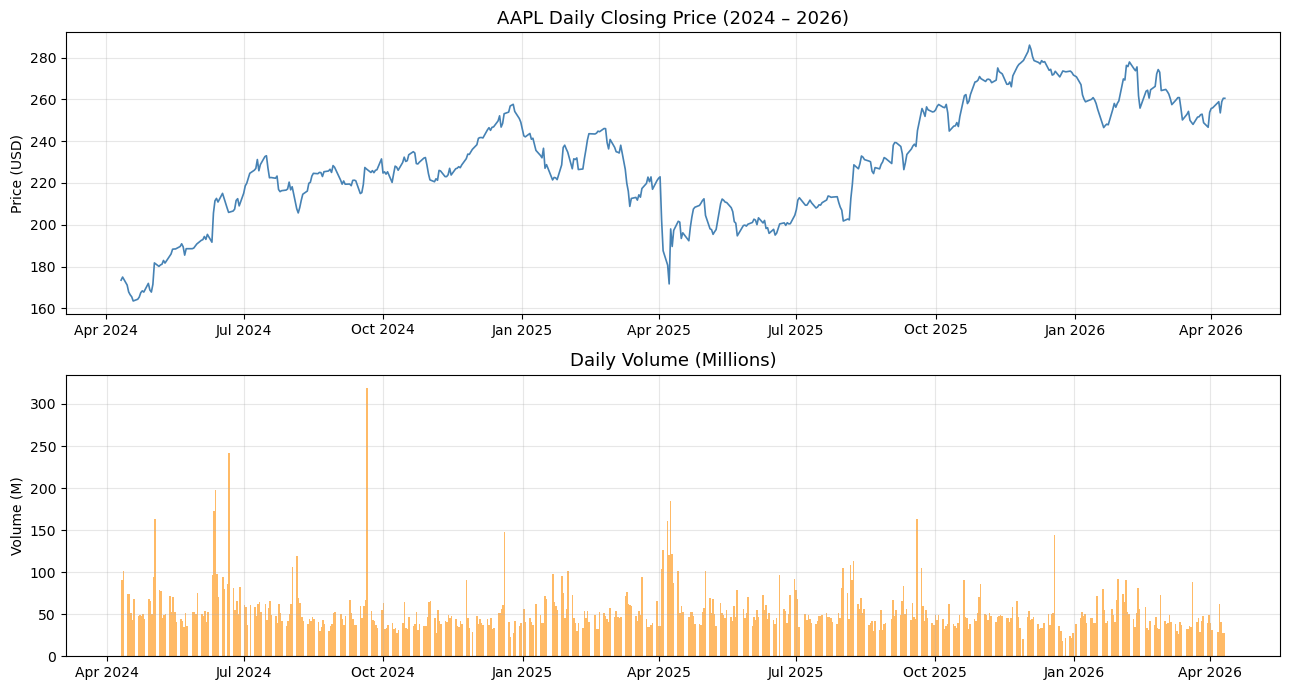

Total trading days  : 501
Date range          : 2024-04-11 → 2026-04-10
Close price range   : $163.51 – $285.92


In [6]:
# ── Visualise the raw closing price ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=1.2)
axes[0].set_title('AAPL Daily Closing Price (2024 – 2026)', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].grid(True, alpha=0.3)

axes[1].bar(df['Date'], df['Volume'] / 1e6, color='darkorange', alpha=0.6, width=1)
axes[1].set_title('Daily Volume (Millions)', fontsize=13)
axes[1].set_ylabel('Volume (M)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total trading days  : {len(df)}')
print(f'Date range          : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Close price range   : ${df["Close"].min():.2f} – ${df["Close"].max():.2f}')

## 3. Preprocessing

### 3.1 Feature Selection & Scaling

All five OHLCV features are used as inputs to give the LSTM richer market context.  
Each feature is independently scaled to **[0, 1]** using `MinMaxScaler`. The `Close` column
scaler is saved separately for inverse-transforming predictions.

In [8]:
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET = 'Close'
LOOK_BACK = 60   # 60 trading days ≈ 3 months of market data

feature_data = df[FEATURES].values

# Fit scalers
scaler_all   = MinMaxScaler(feature_range=(0, 1))
scaler_close = MinMaxScaler(feature_range=(0, 1))

scaled_all   = scaler_all.fit_transform(feature_data)
scaled_close = scaler_close.fit_transform(df[[TARGET]].values)  # for inverse transform

print(f'Feature matrix shape  : {scaled_all.shape}')
print(f'Features used         : {FEATURES}')
print(f'Look-back window      : {LOOK_BACK} days')

Feature matrix shape  : (501, 5)
Features used         : ['Open', 'High', 'Low', 'Close', 'Volume']
Look-back window      : 60 days


### 3.2 Sequence Construction

Each sample `X[i]` is a `(60, 5)` window of scaled OHLCV values.  
The target `y[i]` is the **scaled Close price** at the next day `t+1`.

In [10]:
def create_sequences(features_scaled, close_scaled, look_back):
    """
    Build (X, y) pairs for next-day close prediction.
    X shape: (samples, look_back, n_features)
    y shape: (samples,)  — next-day scaled Close
    """
    X, y = [], []
    for i in range(look_back, len(features_scaled)):
        X.append(features_scaled[i - look_back : i])      # window of past N days
        y.append(close_scaled[i, 0])                      # next-day Close (scalar)
    return np.array(X), np.array(y)


X, y = create_sequences(scaled_all, scaled_close, LOOK_BACK)

print(f'X shape : {X.shape}   → (samples, look_back, features)')
print(f'y shape : {y.shape}   → (samples,)')

X shape : (441, 60, 5)   → (samples, look_back, features)
y shape : (441,)   → (samples,)


### 3.3 Train / Validation / Test Split

- **Train (70%)**: model learns temporal patterns  
- **Validation (15%)**: monitors generalisation during training  
- **Test (15%)**: final held-out evaluation

In [12]:
n_total = len(X)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

print(f'Train      : {X_train.shape}  ({n_train} samples)')
print(f'Validation : {X_val.shape}   ({n_val} samples)')
print(f'Test       : {X_test.shape}   ({n_test} samples)')

Train      : (308, 60, 5)  (308 samples)
Validation : (66, 60, 5)   (66 samples)
Test       : (67, 60, 5)   (67 samples)


## 4. LSTM Model Design

### Architecture Justification

| Component | Choice | Justification |
|---|---|---|
| LSTM Layer 1 | 128 units | Large enough to capture complex temporal dependencies across 60-day windows |
| `return_sequences=True` | Yes (L1) | Required to feed a sequence into the next LSTM layer |
| Dropout 1 | 0.2 | Prevents co-adaptation of neurons; mild regularisation |
| LSTM Layer 2 | 64 units | Refines higher-level temporal patterns extracted by L1 |
| Dropout 2 | 0.2 | Second regularisation stage |
| Dense (32) | ReLU | Intermediate non-linear projection before the output |
| Dense (1) | Linear | Single output, next-day Close price (regression) |
| Optimizer | Adam | Adaptive learning rate; works well for non-stationary financial data |
| Loss | MSE | Standard regression loss; penalises large errors more heavily |

Two stacked LSTM layers are used because a single layer may not be expressive enough
to capture both short-term price momentum and longer multi-week trends simultaneously.

In [14]:
def build_model(look_back, n_features):
    """
    Stacked LSTM model for next-day stock close prediction.

    Architecture:
        LSTM(128) → Dropout(0.2) → LSTM(64) → Dropout(0.2) → Dense(32) → Dense(1)
    """
    model = Sequential([
        # Input(shape=(look_back, n_features), name='input'),
        # LSTM(128, return_sequences=True, name='lstm_1'),
        
        # Layer 1: 128-unit LSTM, returns full sequence for stacking
        LSTM(128, return_sequences=True,
             input_shape=(look_back, n_features),
             name='lstm_1'),
        Dropout(0.2, name='dropout_1'),

        # Layer 2: 64-unit LSTM, returns only the final hidden state
        LSTM(64, return_sequences=False, name='lstm_2'),
        Dropout(0.2, name='dropout_2'),

        # Fully connected layers
        Dense(32, activation='relu', name='dense_hidden'),
        Dense(1,  activation='linear', name='output'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model


model = build_model(look_back=LOOK_BACK, n_features=len(FEATURES))
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [16]:
EPOCHS = 50
BATCH_SIZE = 32

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True,
    verbose = 1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0600 - mae: 0.1911 - val_loss: 0.0554 - val_mae: 0.2301
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0111 - mae: 0.0853 - val_loss: 0.0088 - val_mae: 0.0858
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0095 - mae: 0.0762 - val_loss: 0.0125 - val_mae: 0.1033
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0088 - mae: 0.0701 - val_loss: 0.0186 - val_mae: 0.1285
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0084 - mae: 0.0690 - val_loss: 0.0127 - val_mae: 0.1044
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0077 - mae: 0.0688 - val_loss: 0.0130 - val_mae: 0.1057
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0071 - mae: 0.0639 - val_loss: 0.0082 - val_mae: 0.0821
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0081 - mae: 0.0694 - val_loss: 0.0116 - val_mae: 0.0993
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.008

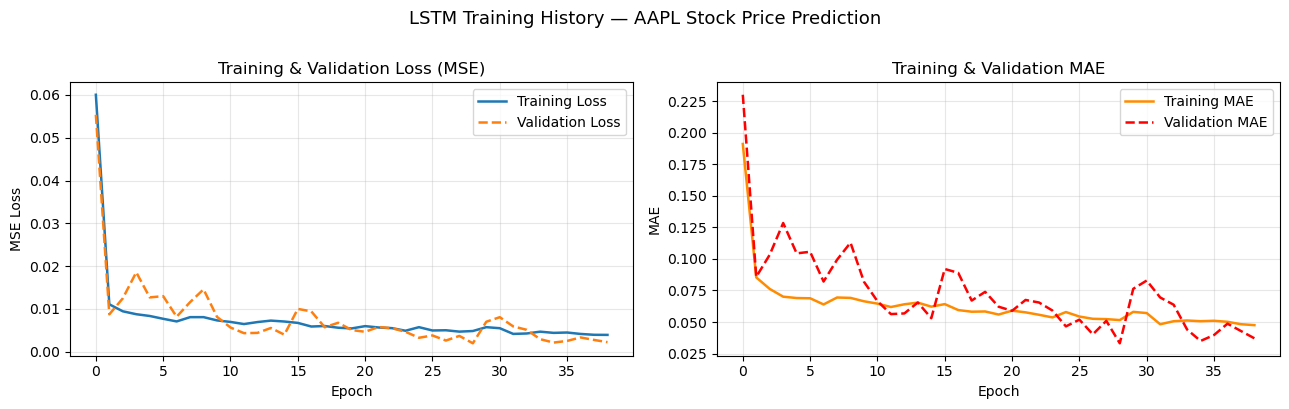

Best epoch (lowest val_loss): 29
Best val_loss               : 0.001987


In [17]:
# ── Training & Validation Loss Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MSE loss
axes[0].plot(history.history['loss'],     label='Training Loss',   linewidth=1.8)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=1.8, linestyle='--')
axes[0].set_title('Training & Validation Loss (MSE)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Training MAE',   linewidth=1.8, color='darkorange')
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=1.8, linestyle='--', color='red')
axes[1].set_title('Training & Validation MAE', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Training History — AAPL Stock Price Prediction', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'Best epoch (lowest val_loss): {best_epoch}')
print(f'Best val_loss               : {min(history.history["val_loss"]):.6f}')

## 6. Evaluation

In [19]:
# ── Generate predictions & inverse-transform to USD ─────────────────────────
y_pred_scaled = model.predict(X_test, verbose=0)

y_pred_usd = scaler_close.inverse_transform(y_pred_scaled)
y_true_usd = scaler_close.inverse_transform(y_test.reshape(-1, 1))

# ── Metrics ─────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
mae  = mean_absolute_error(y_true_usd, y_pred_usd)
mse  = mean_squared_error(y_true_usd, y_pred_usd)

# Mean Absolute Percentage Error
mape = np.mean(np.abs((y_true_usd - y_pred_usd) / y_true_usd)) * 100

print('=' * 40)
print('       TEST SET EVALUATION')
print('=' * 40)
print(f'  RMSE  : ${rmse:.4f}')
print(f'  MAE   : ${mae:.4f}')
print(f'  MSE   : {mse:.6f}')
print(f'  MAPE  : {mape:.2f}%')
print('=' * 40)

       TEST SET EVALUATION
  RMSE  : $6.5990
  MAE   : $5.2367
  MSE   : 43.546874
  MAPE  : 2.00%


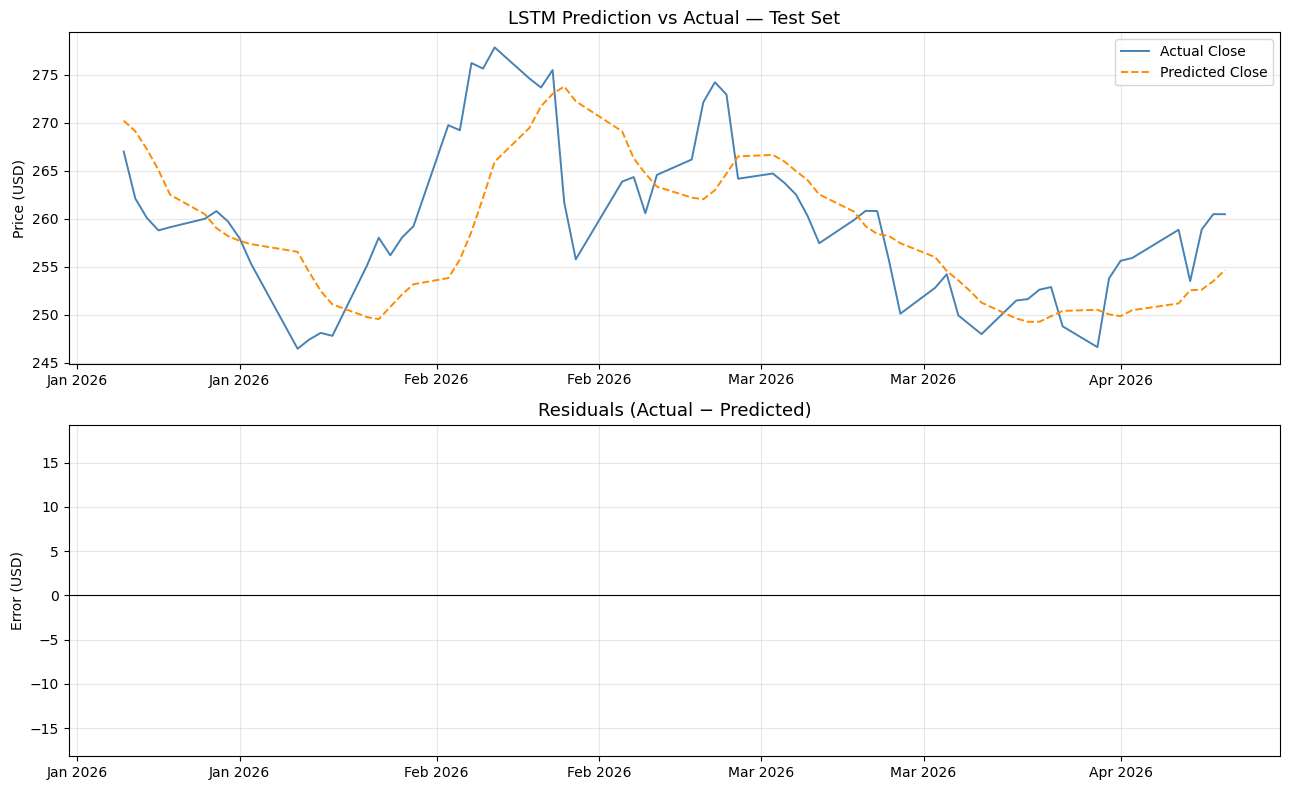

Residual std  : $6.5238
Max overshot  : $17.5756
Max undershot : $-16.4669


In [20]:
# ── Actual vs Predicted plot ─────────────────────────────────────────────────
test_dates = df['Date'].values[LOOK_BACK + n_train + n_val : LOOK_BACK + n_train + n_val + n_test]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# --- Top: full price line ---
axes[0].plot(test_dates, y_true_usd, label='Actual Close',    color='steelblue',  linewidth=1.4)
axes[0].plot(test_dates, y_pred_usd, label='Predicted Close', color='darkorange', linewidth=1.4, linestyle='--')
axes[0].set_title('LSTM Prediction vs Actual — Test Set', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# --- Bottom: residual error ---
residuals = y_true_usd.flatten() - y_pred_usd.flatten()
axes[1].bar(test_dates, residuals, color=['green' if r >= 0 else 'red' for r in residuals], alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals (Actual − Predicted)', fontsize=13)
axes[1].set_ylabel('Error (USD)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Residual std  : ${np.std(residuals):.4f}')
print(f'Max overshot  : ${residuals.max():.4f}')
print(f'Max undershot : ${residuals.min():.4f}')

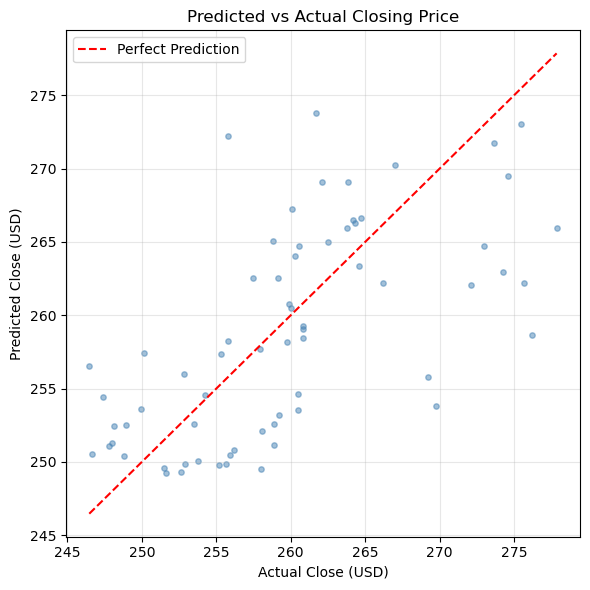

In [21]:
# ── Scatter: Predicted vs Actual ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_true_usd, y_pred_usd, alpha=0.5, s=15, color='steelblue')

# Perfect prediction line
lo, hi = min(y_true_usd.min(), y_pred_usd.min()), max(y_true_usd.max(), y_pred_usd.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect Prediction')

ax.set_xlabel('Actual Close (USD)')
ax.set_ylabel('Predicted Close (USD)')
ax.set_title('Predicted vs Actual Closing Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary Table

In [23]:
summary = pd.DataFrame({
    'Metric':      ['RMSE (USD)', 'MAE (USD)', 'MSE', 'MAPE (%)'],
    'Test Value':  [f'{rmse:.4f}', f'{mae:.4f}', f'{mse:.6f}', f'{mape:.2f}']
})
print(summary.to_string(index=False))

    Metric Test Value
RMSE (USD)     6.5990
 MAE (USD)     5.2367
       MSE  43.546874
  MAPE (%)       2.00


## 8. Model Architecture Summary

In [25]:
arch_summary = pd.DataFrame([
    {'Layer': 'Input',       'Config': f'(batch, {LOOK_BACK}, {len(FEATURES)})', 'Parameters': '—'},
    {'Layer': 'LSTM-1',      'Config': '128 units, return_sequences=True',       'Parameters': 'learned'},
    {'Layer': 'Dropout-1',   'Config': 'rate=0.2',                               'Parameters': '—'},
    {'Layer': 'LSTM-2',      'Config': '64 units, return_sequences=False',       'Parameters': 'learned'},
    {'Layer': 'Dropout-2',   'Config': 'rate=0.2',                               'Parameters': '—'},
    {'Layer': 'Dense-hidden','Config': '32 units, ReLU',                         'Parameters': 'learned'},
    {'Layer': 'Dense-output','Config': '1 unit, Linear',                         'Parameters': 'learned'},
    {'Layer': 'Optimizer',   'Config': 'Adam (lr=0.001)',                        'Parameters': '—'},
    {'Layer': 'Loss',        'Config': 'Mean Squared Error (MSE)',               'Parameters': '—'},
])
print(arch_summary.to_string(index=False))

       Layer                           Config Parameters
       Input                   (batch, 60, 5)          —
      LSTM-1 128 units, return_sequences=True    learned
   Dropout-1                         rate=0.2          —
      LSTM-2 64 units, return_sequences=False    learned
   Dropout-2                         rate=0.2          —
Dense-hidden                   32 units, ReLU    learned
Dense-output                   1 unit, Linear    learned
   Optimizer                  Adam (lr=0.001)          —
        Loss         Mean Squared Error (MSE)          —
